# Import Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Original_Customer_Data.csv'
df = pd.read_csv(file_path)
df.head(5)

Mounted at /content/drive


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [3]:
# We drop column 'Customer_ID' first
df = df.drop('Customer_ID', axis=1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6418 entries, 0 to 6417
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       6418 non-null   object 
 1   Age                          6418 non-null   int64  
 2   Married                      6418 non-null   object 
 3   State                        6418 non-null   object 
 4   Number_of_Referrals          6418 non-null   int64  
 5   Tenure_in_Months             6418 non-null   int64  
 6   Value_Deal                   2870 non-null   object 
 7   Phone_Service                6418 non-null   object 
 8   Multiple_Lines               5796 non-null   object 
 9   Internet_Service             6418 non-null   object 
 10  Internet_Type                5028 non-null   object 
 11  Online_Security              5028 non-null   object 
 12  Online_Backup                5028 non-null   object 
 13  Device_Protection_

In [5]:
df.describe()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
count,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000
mean,47.070739,7.427859,17.342786,63.652867,2280.374858,1.924944,6.718604,748.703468,3033.871987
std,16.703633,4.621519,10.576391,31.188823,2268.049985,7.849083,24.722533,847.672844,2866.505426
min,18.000000,0.000000,1.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,33.000000,3.000000,8.000000,30.562500,395.725000,0.000000,0.000000,70.805000,603.742500
50%,46.000000,7.000000,16.000000,70.100000,1396.125000,0.000000,0.000000,407.475000,2108.635000
75%,60.000000,11.000000,27.000000,89.750000,3783.600000,0.000000,0.000000,1182.917500,4801.537500
max,85.000000,15.000000,36.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


# Eploratory Data Analysis & Preprocessing

First , we view the distribution of Customer Status

In [6]:
customer_status_rates = df['Customer_Status'].value_counts(normalize=True) * 100
print("Rate of each category in 'Customer_Status' (%):")
print(customer_status_rates)

Rate of each category in 'Customer_Status' (%):
Customer_Status
Stayed     66.609536
Churned    26.986600
Joined      6.403864
Name: proportion, dtype: float64


/tmp/ipykernel_1899/852257707.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Customer_Status', palette='viridis')


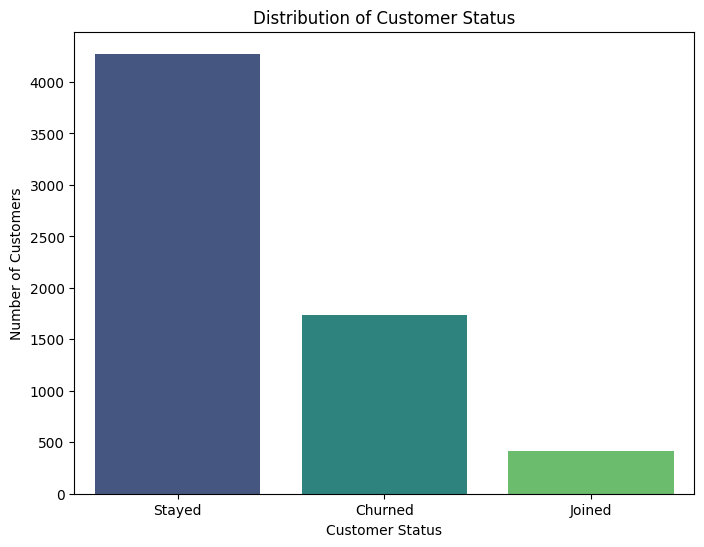

In [7]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Customer_Status', palette='viridis')
plt.title('Distribution of Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')
plt.show()

/tmp/ipykernel_1899/1753424781.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Customer_Status', y='Tenure_in_Months', palette='viridis')


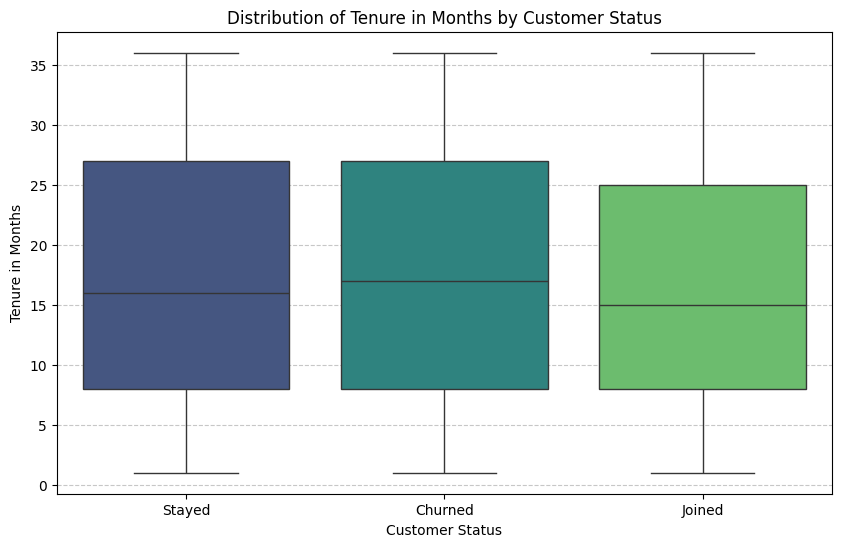

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Customer_Status', y='Tenure_in_Months', palette='viridis')
plt.title('Distribution of Tenure in Months by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Tenure in Months')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [9]:
#View 5 "Joined" customers who have been with the company for over 12 months.
anomaly_joined = df[(df['Customer_Status'] == 'Joined') & (df['Tenure_in_Months'] > 12)]
anomaly_joined.head()

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
17,Female,67,No,Gujarat,13,19,Deal 5,Yes,Yes,Yes,...,Bank Withdrawal,72.10,72.10,0.0,0,7.77,79.87,Joined,NaN,NaN
98,Female,58,Yes,Karnataka,11,18,NaN,Yes,No,No,...,Credit Card,19.95,58.00,0.0,0,8.07,66.07,Joined,NaN,NaN
132,Female,47,Yes,Gujarat,6,33,Deal 5,Yes,No,Yes,...,Bank Withdrawal,84.30,235.05,0.0,0,41.16,276.21,Joined,NaN,NaN
156,Male,27,No,West Bengal,2,20,NaN,Yes,No,Yes,...,Bank Withdrawal,90.40,268.45,0.0,0,94.44,362.89,Joined,NaN,NaN
206,Male,48,No,Andhra Pradesh,14,21,NaN,Yes,Yes,No,...,Credit Card,26.40,121.25,0.0,0,101.61,222.86,Joined,NaN,NaN


The 'Joined' customer group typically only has 'Tenure_in_months' for a few months; however, we see that the seniority distribution of this group is exactly the same as the 'Stayed' and 'Churned' groups (median up to 15 months). I decided to completely remove this 'Joined' group from the dataset, suspecting that the data may have been mislabeled, to avoid affecting the model later.

In [10]:
df = df[df['Customer_Status'] != 'Joined']

In [11]:
# Create a Target column from 'Customer_Status'
df['Churn'] = df['Customer_Status'].apply(lambda x: 1 if x == 'Churned' else 0)
# Drop column 'Customer_Status'
df = df.drop('Customer_Status', axis=1)
# We see that columns : 'Churn_Reason' & 'Churn_Category' may make data leakage when input in model , so we drop them .
df = df.drop(['Churn_Reason', 'Churn_Category'], axis=1)

/tmp/ipykernel_1899/4176078476.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


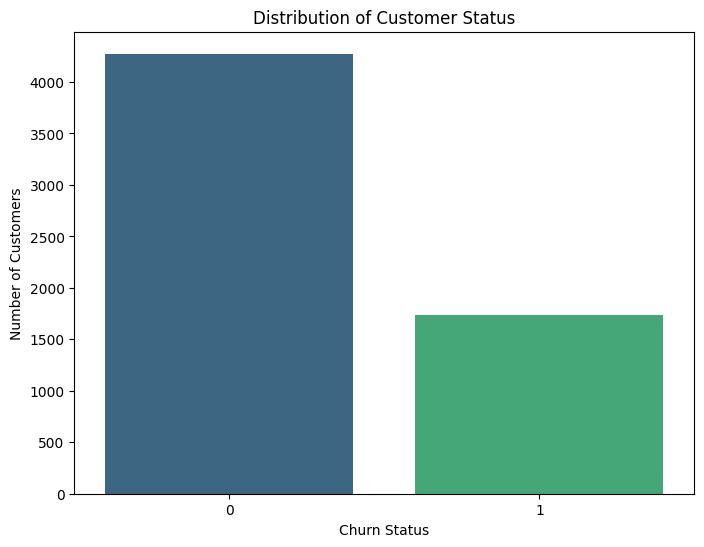

In [12]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribution of Customer Status')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

In [13]:
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"Unique values for column '{column}':")
        print(df[column].unique())
        print("\n")

Unique values for column 'Gender':
['Male' 'Female']


Unique values for column 'Married':
['No' 'Yes']


Unique values for column 'State':
['Delhi' 'Maharashtra' 'West Bengal' 'Karnataka' 'Tamil Nadu' 'Telangana'
 'Gujarat' 'Uttar Pradesh' 'Rajasthan' 'Bihar' 'Andhra Pradesh'
 'Madhya Pradesh' 'Chhattisgarh' 'Punjab' 'Jharkhand' 'Haryana'
 'Jammu & Kashmir' 'Assam' 'Uttarakhand' 'Odisha' 'Kerala' 'Puducherry']


Unique values for column 'Value_Deal':
[nan 'Deal 5' 'Deal 4' 'Deal 1' 'Deal 2' 'Deal 3']


Unique values for column 'Phone_Service':
['Yes' 'No']


Unique values for column 'Multiple_Lines':
['No' 'Yes' nan]


Unique values for column 'Internet_Service':
['Yes' 'No']


Unique values for column 'Internet_Type':
['Cable' 'Fiber Optic' 'DSL' nan]


Unique values for column 'Online_Security':
['No' 'Yes' nan]


Unique values for column 'Online_Backup':
['Yes' 'No' nan]


Unique values for column 'Device_Protection_Plan':
['No' 'Yes' nan]


Unique values for column 'Premium_Suppor

## Handle Missing Values

Handling Nan for service groups

In [14]:
import pandas as pd

# 1. List of service columns that depend on the Internet
internet_services = [
'Internet_Type', 'Online_Security', 'Online_Backup',
'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV',
'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data'
]

# 2. Count the total number of NaNs for these columns across the entire dataset
total_nans = df[internet_services].isna().sum()

# 3. Count the number of NaNs for these columns ONLY IN the group of customers who do not use the Internet
no_internet_mask = df['Internet_Service'] == 'No'
nans_in_no_internet_group = df[no_internet_mask][internet_services].isna().sum()

# 4. Print the comparison table
check_df = pd.DataFrame({
'Total missing rows (NaN)': total_nans,

'Number of NaNs in the "No Internet" group': nans_in_no_internet_group
})

# Add a conclusion column: If the two columns are equal -> Our assumption is 100% correct
check_df['Match 100%?'] = check_df['Total missing rows (NaN)'] == check_df['Number of NaNs in the "No Internet" group']

print("--- INTERNET SERVICE CROSS-CHECK RESULTS ---")

display(check_df)

--- INTERNET SERVICE CROSS-CHECK RESULTS ---


,Total missing rows (NaN),"Number of NaNs in the ""No Internet"" group",Match 100%?
Internet_Type,1223,1223,True
Online_Security,1223,1223,True
Online_Backup,1223,1223,True
Device_Protection_Plan,1223,1223,True
Premium_Support,1223,1223,True
Streaming_TV,1223,1223,True
Streaming_Movies,1223,1223,True
Streaming_Music,1223,1223,True
Unlimited_Data,1223,1223,True


We see that all the Nan of services columns originated from 'No' from column 'Internet_Service'

So we decided to replace every nan of this group with 'No Internet Service'

In [15]:
internet_services = [
    'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV',
    'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data'
]
for col in internet_services:
    df[col] = df[col].fillna('No Internet Service')

In [16]:
# We continue check for Nan of 'Multiple_Lines' and 'Phone_Service' = 'No'
# 2. Count the total number of NaNs for these columns across the entire dataset
total_nans = df['Multiple_Lines'].isna().sum()

no_phone_mask = df['Phone_Service'] == 'No'
nans_in_no_phone_group = df[no_phone_mask]['Multiple_Lines'].isna().sum()

# 4. Print the comparison table
check_df = pd.DataFrame({
'Total missing rows (NaN)': [total_nans],

'Number of NaNs in the "No Phone" group': [nans_in_no_phone_group]
}, index=['Multiple_Lines'])

# Add a conclusion column: If the two columns are equal -> Our assumption is 100% correct
check_df['Match 100%?'] = check_df['Total missing rows (NaN)'] == check_df['Number of NaNs in the "No Phone" group']

print("--- PHONE SERVICE CROSS-CHECK RESULTS ---")

display(check_df)

--- PHONE SERVICE CROSS-CHECK RESULTS ---


,Total missing rows (NaN),"Number of NaNs in the ""No Phone"" group",Match 100%?
Multiple_Lines,590,590,True


We continue to see that Nan of column 'Multiple_Lines' originated from 'No Phone Service' . We decided to impute those Nan with 'No Phone Service'

In [17]:
df['Multiple_Lines'] = df['Multiple_Lines'].fillna('No Phone Service')

In [18]:
# We impute Nan of column 'Value_Deal' with 'No Deal'
df['Value_Deal'] = df['Value_Deal'].fillna('No Deal')

After handling Nan values , we re-check dataset

In [19]:
# check null of all features
df.isnull().sum()

,0
Gender,0
Age,0
Married,0
State,0
Number_of_Referrals,0
Tenure_in_Months,0
Value_Deal,0
Phone_Service,0
Multiple_Lines,0
Internet_Service,0


## Correlation Matrix

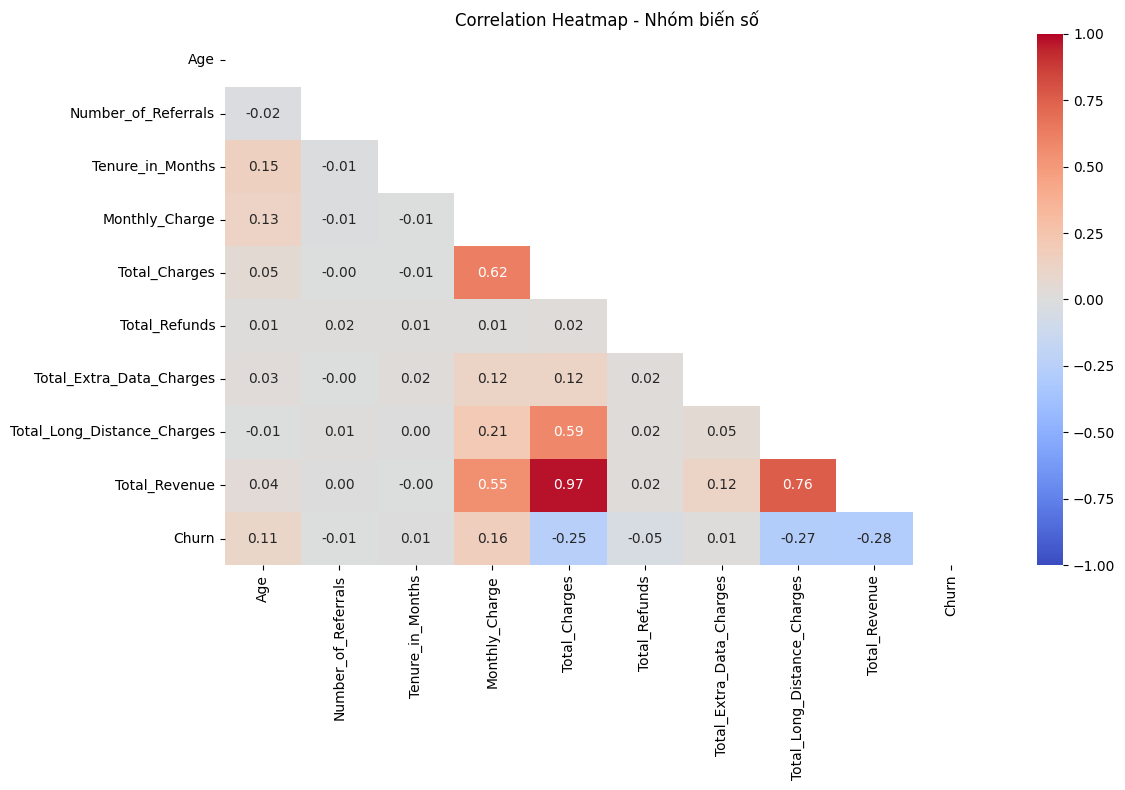

In [20]:
# we plot correlation matrix for numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
# (Pearson)
corr_matrix = df[num_cols].corr()


plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap - Nhóm biến số")
plt.tight_layout()
plt.show()

In [21]:
# Drop Total_Revenue to resolve multicollinearity at 0.97 and 0.76
df = df.drop(columns=['Total_Revenue'])

The column Tenure_in_Months has a correlation of almost zero with every columns (-0.01 with Total_Charges and 0.01 with Churn).

This is a huge paradox.

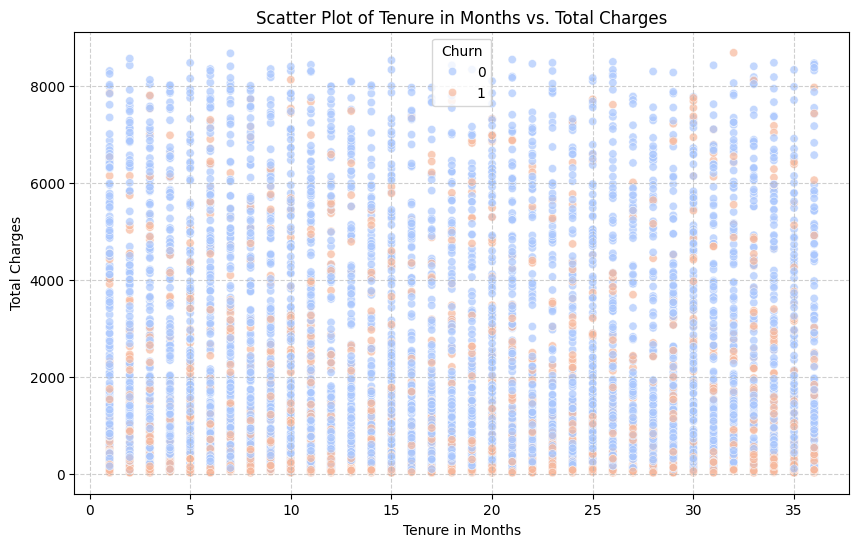

In [22]:
# We plot scatter plot between 'Tenure_in_Months & 'Total_Charges' to see if they have linear relation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Tenure_in_Months', y='Total_Charges', hue='Churn', palette='coolwarm', alpha=0.7)
plt.title('Scatter Plot of Tenure in Months vs. Total Charges')
plt.xlabel('Tenure in Months')
plt.ylabel('Total Charges')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

We see that there is no linear relation between Tenure & Total charges , this can't be true , as in reality , the Tenure of Use is always directly proportional to the total charges.

We concluded that feature 'Tenure_In_Months' is an error feature. We'll drop this column then replace with replace with a new 'Tenure' feature

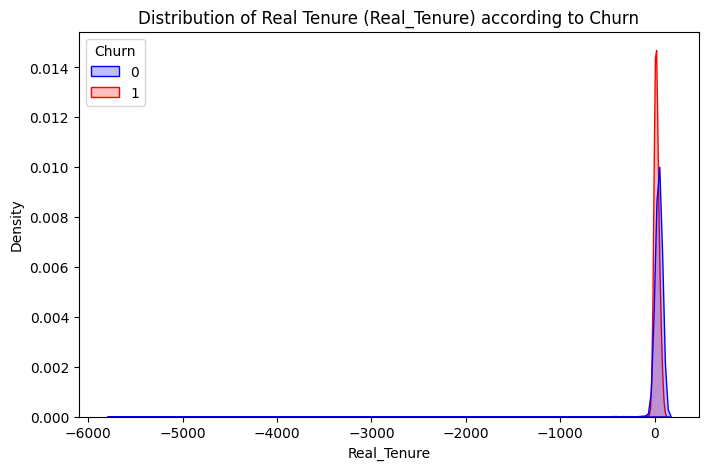

In [23]:
# Drop feature 'Tenure_in_Months'
df = df.drop(columns=['Tenure_in_Months'])
# 2. Restore the Real_Tenure variable mathematically
# (Add a small increment to the denominator to avoid division by zero errors if any)
df['Real_Tenure'] = df['Total_Charges'] / (df['Monthly_Charge'] + 0.0001)

# Round the number of months
df['Real_Tenure'] = df['Real_Tenure'].round()

# 3. Redraw the KDE chart to check the results

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Real_Tenure', hue='Churn', fill=True, common_norm=False, palette=['blue', 'red'])
plt.title('Distribution of Real Tenure (Real_Tenure) according to Churn')
plt.show()

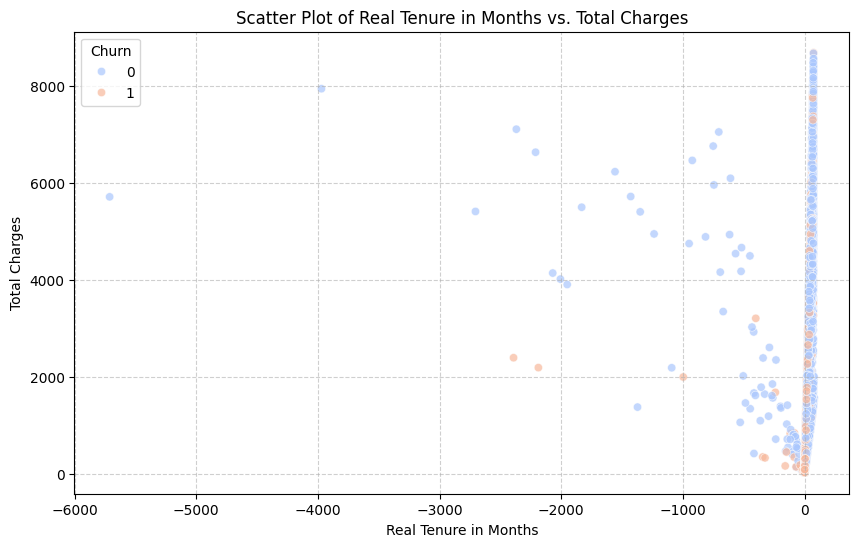

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Real_Tenure', y='Total_Charges', hue='Churn', palette='coolwarm', alpha=0.7)
plt.title('Scatter Plot of Real Tenure in Months vs. Total Charges')
plt.xlabel('Real Tenure in Months')
plt.ylabel('Total Charges')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

We observed that so many Real Tenure values are negative , we find the root-cause of this phenomenon

In [25]:
# Filter out rows where Real_Tenure < 0
anomalies = df[df['Real_Tenure'] < 0]

# Print out their Total_Charges and Monthly_Charge
print(f"Number of negative rows: {len(anomalies)}")
display(anomalies[['Monthly_Charge', 'Total_Charges', 'Real_Tenure']].head(10))

Number of negative rows: 101


,Monthly_Charge,Total_Charges,Real_Tenure
1,-4.0,542.40,-136.0
32,-2.0,7942.15,-3971.0
168,-3.0,465.70,-155.0
229,-8.0,4539.60,-567.0
330,-1.0,343.95,-344.0
420,-10.0,840.10,-84.0
562,-2.0,4138.90,-2070.0
676,-4.0,24.80,-6.0
678,-7.0,825.70,-118.0
686,-9.0,4663.40,-518.0


In [26]:
# We can see that column 'Monthly_Charge' has 101 negative values , in fact , the charge can't be negative
# As 101 rows accounts a small rate over the whole dataset , so we decide to drop these value
df = df[df['Monthly_Charge'] >= 0]

In [27]:
anomalies = df[df['Real_Tenure'] < 0]

# Print out their Total_Charges and Monthly_Charge
print(f"Number of negative rows: {len(anomalies)}")
display(anomalies[['Monthly_Charge', 'Total_Charges', 'Real_Tenure']].head(10))

Number of negative rows: 0


,Monthly_Charge,Total_Charges,Real_Tenure


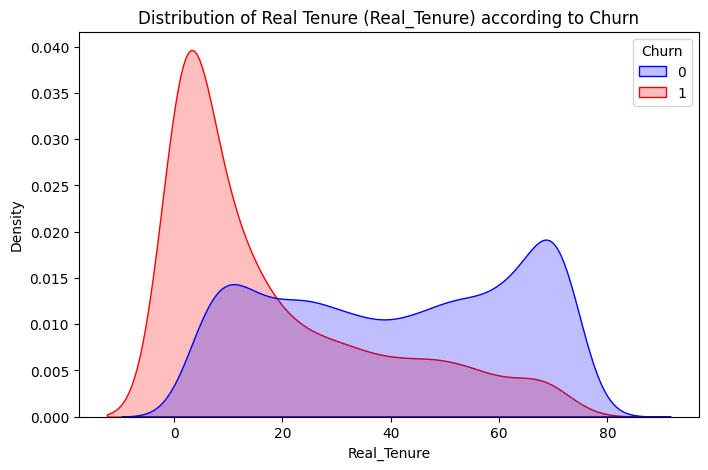

In [28]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Real_Tenure', hue='Churn', fill=True, common_norm=False, palette=['blue', 'red'])
plt.title('Distribution of Real Tenure (Real_Tenure) according to Churn')
plt.show()

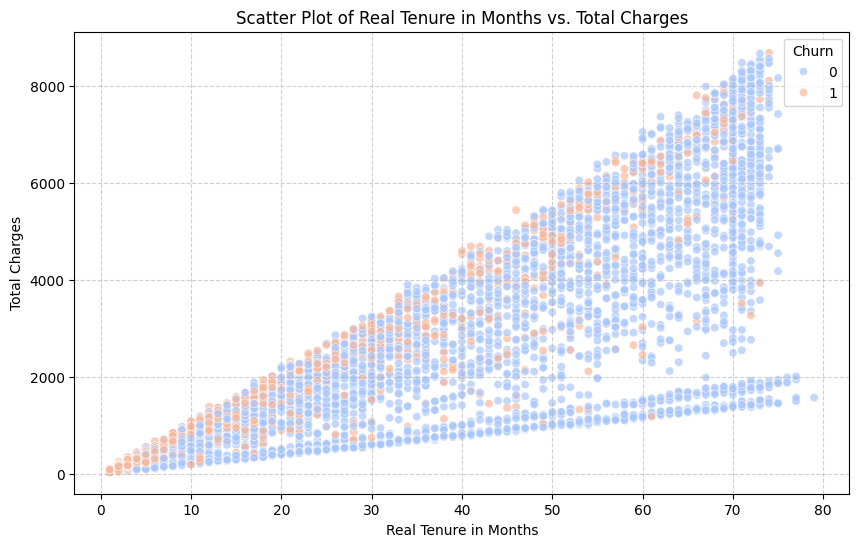

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Real_Tenure', y='Total_Charges', hue='Churn', palette='coolwarm', alpha=0.7)
plt.title('Scatter Plot of Real Tenure in Months vs. Total Charges')
plt.xlabel('Real Tenure in Months')
plt.ylabel('Total Charges')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Try Removing Weak/Noise Features

We will use a statistical approach to force the computer to score which variable is the strongest. The best tool for this is the Chi-Square test.

Objective: The Chi-Square test will calculate a value called the p-value.

- If p-value < 0.05: That variable has a significant impact on customer churn (Very important).

- If p-value > 0.05: The difference is only random; that variable is junk (Can be dropped).

In [30]:
from scipy.stats import chi2_contingency

# Filter all Category columns (object)
cat_cols = df.select_dtypes(include=['object']).columns
target_col = 'Churn'

chi2_results = []

for col in cat_cols:


# Create a crosstab between the current variable and Target
  contingency_table = pd.crosstab(df[col], df[target_col])

# Run the Chi-Square test
  chi2, p, dof, expected = chi2_contingency(contingency_table)

  chi2_results.append({
  'Feature': col,

  'P-Value': p,

  'Importance': 'High' if p < 0.001 else ('Medium' if p < 0.05 else 'Low/Noise')

  })

# Transform into a DataFrame and sort from most important to least important
feature_importance_df = pd.DataFrame(chi2_results).sort_values(by='P-Value')

print("--- RANKING OF IMPORTANCE OF CATEGORY VARIABLES ---")

display(feature_importance_df.reset_index(drop=True))

--- RANKING OF IMPORTANCE OF CATEGORY VARIABLES ---


,Feature,P-Value,Importance
0,Contract,0.000000e+00,High
1,Online_Security,1.190624e-170,High
2,Premium_Support,9.065685e-163,High
3,Value_Deal,5.539687e-137,High
4,Online_Backup,5.801044e-116,High
5,Device_Protection_Plan,4.336561e-114,High
6,Internet_Type,3.409444e-112,High
7,Streaming_Music,4.132619e-70,High
8,Streaming_Movies,4.533315e-69,High
9,Streaming_TV,5.887792e-69,High


After using Chi-square to do Bivariate Analysis between 'Churn' and categorical features , there are 4 columns considered 'weak importance' to Target

However , we can't drop these 4 features immediately. We'll employ two Baseline Models using Random Forest
  - First model : keep all categorical features
  - Second model : drop 4 'weak features'

We compare result of two models on validation set , then decide which one we will use later

In [31]:
# First , we split dataset into train-validation-test
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Separate variables X and y from df_clean
X = df.drop(columns=['Churn'])
y = df['Churn']

# 1. Save the Test set (15%) - Do not touch it until the end of the project
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

# 2. Divide the remaining Dev set into Train (80%) and Validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=42)

print(f"Number of Trains: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Number of Trains: 4016 | Val: 1004 | Test: 886


In [32]:
# We check again every unique values of all categorical features
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"Unique values for column '{column}':")
        print(df[column].unique())
        print("\n")

Unique values for column 'Gender':
['Male' 'Female']


Unique values for column 'Married':
['No' 'Yes']


Unique values for column 'State':
['Delhi' 'West Bengal' 'Karnataka' 'Tamil Nadu' 'Telangana' 'Maharashtra'
 'Gujarat' 'Uttar Pradesh' 'Rajasthan' 'Bihar' 'Andhra Pradesh'
 'Madhya Pradesh' 'Chhattisgarh' 'Punjab' 'Jharkhand' 'Haryana'
 'Jammu & Kashmir' 'Assam' 'Uttarakhand' 'Odisha' 'Kerala' 'Puducherry']


Unique values for column 'Value_Deal':
['No Deal' 'Deal 5' 'Deal 4' 'Deal 1' 'Deal 2' 'Deal 3']


Unique values for column 'Phone_Service':
['Yes' 'No']


Unique values for column 'Multiple_Lines':
['No' 'Yes' 'No Phone Service']


Unique values for column 'Internet_Service':
['Yes' 'No']


Unique values for column 'Internet_Type':
['Cable' 'Fiber Optic' 'DSL' 'No Internet Service']


Unique values for column 'Online_Security':
['No' 'Yes' 'No Internet Service']


Unique values for column 'Online_Backup':
['Yes' 'No' 'No Internet Service']


Unique values for column 'Device_Pr

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# =========================================================
# 1. PREPARE 2 DATA VERSIONS
# =========================================================
noise_cols = ['Gender', 'Married', 'Phone_Service', 'Multiple_Lines']

# Model A (Remain the same)
X_train_A = X_train.copy()
X_val_A = X_val.copy()

# Model B (Remove 4 variables)
X_train_B = X_train.drop(columns=noise_cols, errors='ignore')
X_val_B = X_val.drop(columns=noise_cols, errors='ignore')

# ==========================================
# 2. SETTING UP THE MANUAL ENCODER
# ==========================================
binary_cols = ['Paperless_Billing']

ordinal_cols = ['Contract']

# Preprocessor constructor (Defines how to transform data)
def create_preprocessor(X_df):

  num_cols = X_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

  # Get the remaining categorical variables (not in binary and ordinal)

  nom_cols = [col for col in X_df.select_dtypes(include=['object']).columns
  if col not in binary_cols + ordinal_cols]

  return ColumnTransformer(
  transformers=[
  ('num', StandardScaler(), num_cols),
  ('bin', OrdinalEncoder(categories=[['No', 'Yes']], handle_unknown='use_encoded_value', unknown_value=-1), binary_cols),
  ('ord', OrdinalEncoder(categories=[['Month-to-Month', 'One Year', 'Two Year']], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
  ('nom', OneHotEncoder(handle_unknown='ignore', drop='first'), nom_cols)
  ]
)

preprocessor_A = create_preprocessor(X_train_A)
preprocessor_B = create_preprocessor(X_train_B)

# ==========================================
# 3. PERFORM DATA TRANSFORMATION (MANUAL TRANSFORM)
# ==========================================
# IMPORTANT NOTE: fit_transform on Train, only transform on Val
X_train_A_encoded = preprocessor_A.fit_transform(X_train_A)
X_val_A_encoded = preprocessor_A.transform(X_val_A)

X_train_B_encoded = preprocessor_B.fit_transform(X_train_B)
X_val_B_encoded = preprocessor_B.transform(X_val_B)

# ==========================================
# 4. TRAINING AND EVALUATION (NOT USED) PIPELINE)
# =========================================================
print("--- TRAINING MODEL A (FULL VARIABLES) ---")
rf_A = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_A.fit(X_train_A_encoded, y_train)
y_pred_A = rf_A.predict(X_val_A_encoded)
print(classification_report(y_val, y_pred_A))

print("\n--- TRAINING MODEL B (REMOVE 4 VARIABLES) ---")
rf_B = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_B.fit(X_train_B_encoded, y_train)
y_pred_B = rf_B.predict(X_val_B_encoded)
print(classification_report(y_val, y_pred_B))

--- TRAINING MODEL A (FULL VARIABLES) ---
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       714
           1       0.84      0.62      0.71       290

    accuracy                           0.86      1004
   macro avg       0.85      0.79      0.81      1004
weighted avg       0.85      0.86      0.85      1004


--- TRAINING MODEL B (REMOVE 4 VARIABLES) ---
              precision    recall  f1-score   support

           0       0.87      0.95      0.90       714
           1       0.83      0.64      0.72       290

    accuracy                           0.86      1004
   macro avg       0.85      0.79      0.81      1004
weighted avg       0.85      0.86      0.85      1004



We observe that Model B performs better than Model A with Recall = 0.64 and F1 = 0.72 (Class 1).

We confidently conclude that removing the four redundant variables from the Chi-square analysis results is correct.

## Creating New Features

/tmp/ipykernel_1899/4148760892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, palette='viridis')
/tmp/ipykernel_1899/4148760892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, palette='viridis')
/tmp/ipykernel_1899/4148760892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, palette='viridis')
/tmp/ipykernel_1899/4148760892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legen

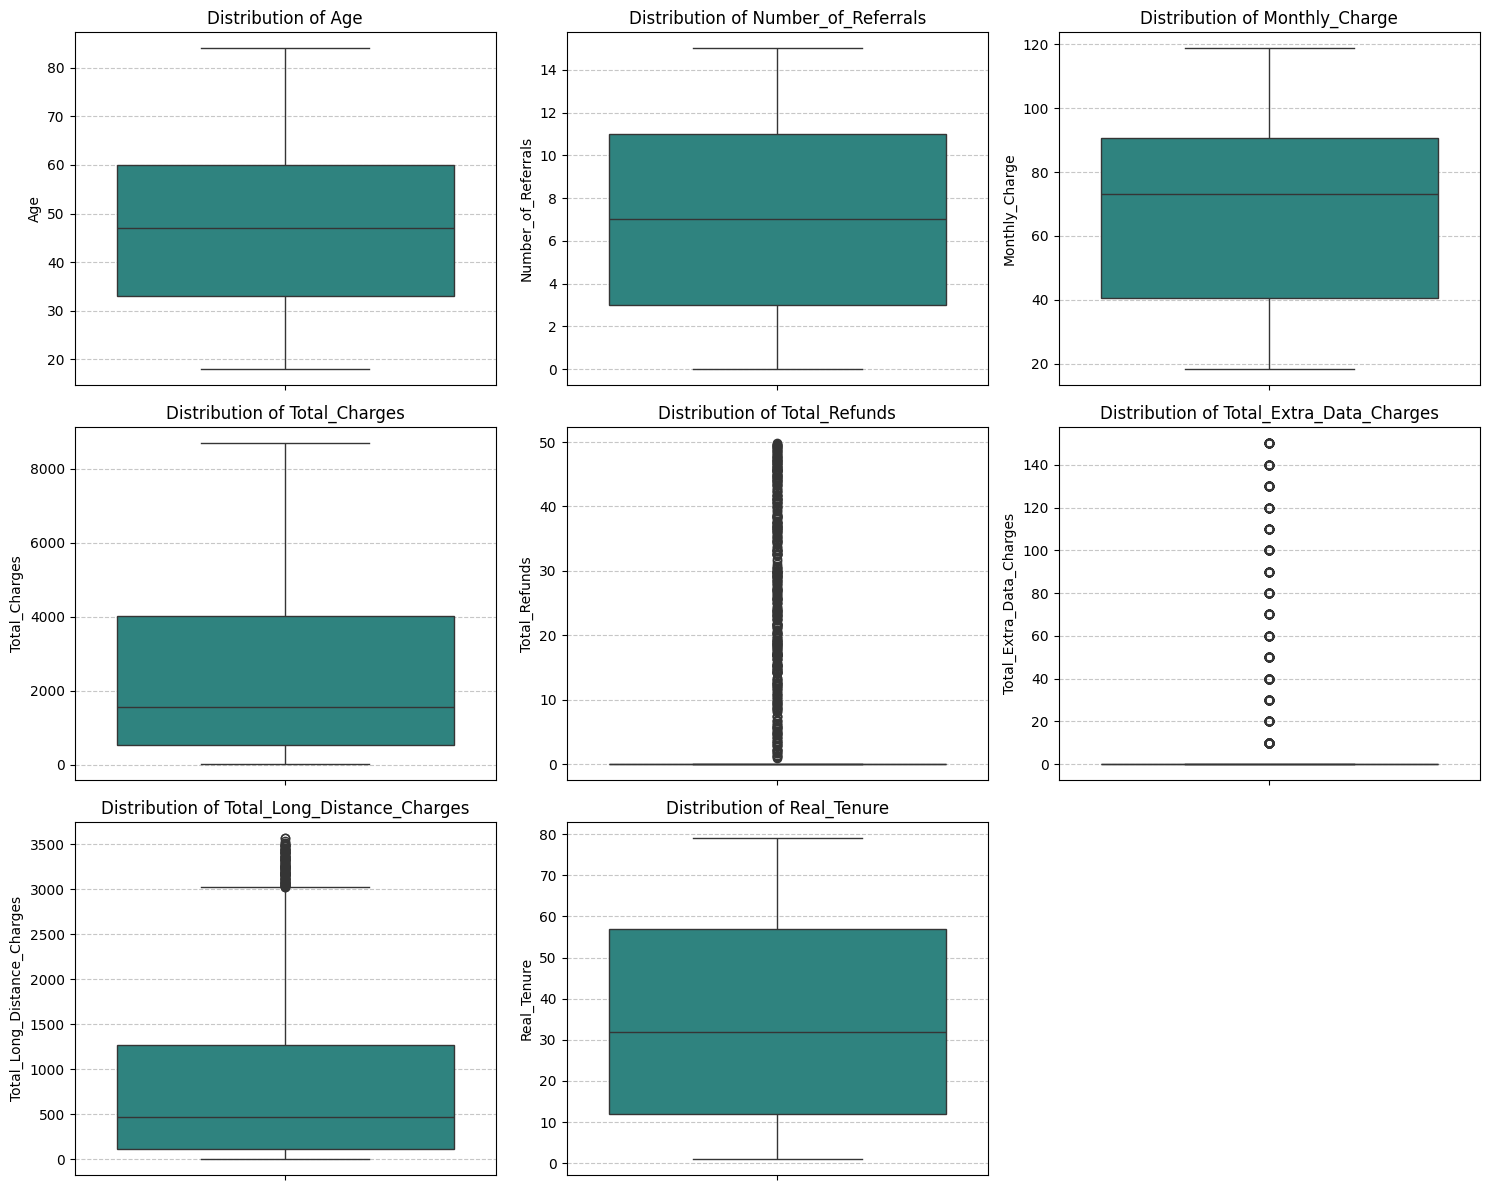

In [34]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Determine the number of rows and columns for subplots
num_features = len(numerical_cols)
num_cols = 3 # You can adjust this as needed
num_rows = (num_features + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 5, num_rows * 4)) # Adjust figure size dynamically

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(data=df, y=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [35]:
import pandas as pd
import numpy as np

# =========================================================
# 1. WRITE THE FEATURE ENGINEERING FUNCTION
# =========================================================
def apply_feature_engineering(df_input):
  df = df_input.copy()

  # --- CREATE NEW VARIABLE ---

  # 1. Total_Services (Count of services)
  service_cols = ['Online_Security', 'Online_Backup', 'Device_Protection_Plan',
  'Premium_Support', 'Streaming_TV', 'Streaming_Movies', 'Streaming_Music']
  df['Total_Services'] = df[service_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

  #2. Tenure_to_Monthly_Charge_Ratio
  df['Tenure_to_Monthly_Charge_Ratio'] = df['Real_Tenure'] / (df['Monthly_Charge'] + 1e-5)

  #3. Age_Group (Binning Age)
  # Divided into 3 groups: 0-34 (Young), 35-59 (Adult), 60+ (Senior)
  df['Age_Group'] = pd.cut(df['Age'], bins=[0, 35, 60, 150], labels=['Young', 'Adult', 'Senior'], right=False)
  df['Age_Group'] = df['Age_Group'].astype('object') # Cast object type to include in OneHotEncoder

  #4. Binary Flags (1 if (Has Refunds are incurred, 0 otherwise)

  df['Has_Refund'] = (df['Total_Refunds'] > 0).astype(int)

  df['Has_Extra_Data'] = (df['Total_Extra_Data_Charges'] > 0).astype(int)

  # 5. Avg_Monthly_Long_Distance (Average monthly long-distance call charges)

  df['Avg_Monthly_Long_Distance'] = df['Total_Long_Distance_Charges'] / (df['Real_Tenure'] + 1e-5)

  # --- REMOVE ROOT COLUMN ---

  # Note: We keep Total_Long_Distance_Charges because the ratio (number 5) measures another aspect.

  cols_to_drop = ['Age', 'Total_Refunds', 'Total_Extra_Data_Charges']

  df = df.drop(columns=cols_to_drop, errors='ignore')

  return df

# ==========================================
# 2. APPLY TO DATA
# ==========================================
# X_train_B and X_val_B are the datasets from which the 4 noise variables were removed in the previous step.
X_train_eng = apply_feature_engineering(X_train_B)
X_val_eng = apply_feature_engineering(X_val_B)

print(f"Number of columns in Baseline dataset: {X_train_B.shape[1]}")

print(f"Number of columns in Engineered dataset: {X_train_eng.shape[1]}")

# ========================================================
# 3. CODING AND COMPARISON (A/B TEST)
# =========================================================
# Call back the create_preprocessor function from the previous step
preprocessor_base = create_preprocessor(X_train_B)
preprocessor_eng = create_preprocessor(X_train_eng)

# Transform
X_train_base_encoded = preprocessor_base.fit_transform(X_train_B)
X_val_base_encoded = preprocessor_base.transform(X_val_B)

X_train_eng_encoded = preprocessor_eng.fit_transform(X_train_eng)
X_val_eng_encoded = preprocessor_eng.transform(X_val_eng)

# Train & Review
print("\n--- MODEL BASELINE (ONLY REMOVE 4 VARIABLES INTERFERENCE) ---")
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_base.fit(X_train_base_encoded, y_train)
y_pred_base = rf_base.predict(X_val_base_encoded)
print(classification_report(y_val, y_pred_base))

print("\n--- MODEL ENGINEERED (CREATE 6 NEW VARIABLES, REMOVE 3 ORIGINAL VARIABLES) ---")
rf_eng = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_eng.fit(X_train_eng_encoded, y_train)
y_pred_eng = rf_eng.predict(X_val_eng_encoded)
print(classification_report(y_val, y_pred_eng))

Number of columns in Baseline dataset: 23
Number of columns in Engineered dataset: 26

--- MODEL BASELINE (ONLY REMOVE 4 VARIABLES INTERFERENCE) ---
              precision    recall  f1-score   support

           0       0.87      0.95      0.90       714
           1       0.83      0.64      0.72       290

    accuracy                           0.86      1004
   macro avg       0.85      0.79      0.81      1004
weighted avg       0.85      0.86      0.85      1004


--- MODEL ENGINEERED (CREATE 6 NEW VARIABLES, REMOVE 3 ORIGINAL VARIABLES) ---
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       714
           1       0.80      0.62      0.70       290

    accuracy                           0.85      1004
   macro avg       0.83      0.78      0.80      1004
weighted avg       0.84      0.85      0.84      1004



After creating new features, we noticed that the Model's performance decreased.

We then proceeded to refine which variables were useful and which were not.

In [36]:
# 1. Get a list of variable names after passing through the encoder (OneHotEncoder, StandardScaler...)
feature_names = preprocessor_eng.get_feature_names_out()

# 2. Get the importance score from the model rf_eng
importances = rf_eng.feature_importances_

# 3. Create a DataFrame for easy viewing
df_importance = pd.DataFrame({
  'Feature': feature_names,

  'Importance': importances
})

# 4. Sort from highest to lowest and display the Top 15
df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)
print("--- TOP 15 MOST IMPORTANT VARIABLES IN THE ENGINEERED MODEL ---")
display(df_importance.head(15))

# 5. View where the newly created variables are located in the ranking table
new_features = ['Total_Services', 'Tenure_to_Monthly_Charge_Ratio', 'Age_Group', 'Has_Refund', 'Has_Extra_Data', 'Avg_Monthly_Long_Distance']
print("\n--- RANKING OF NEWLY CREATED VARIABLES ---")
# Filter variables containing the keyword of the new variable (because after encoding, the variable name may have suffixes added)
for feature in new_features:
    matching_rows = df_importance[df_importance['Feature'].str.contains(feature, case=False)]
    if not matching_rows.empty:
        display(matching_rows)

--- TOP 15 MOST IMPORTANT VARIABLES IN THE ENGINEERED MODEL ---


,Feature,Importance
0,num__Tenure_to_Monthly_Charge_Ratio,0.135121
1,ord__Contract,0.126544
2,num__Real_Tenure,0.099778
3,num__Total_Charges,0.088448
4,num__Total_Long_Distance_Charges,0.067342
5,num__Monthly_Charge,0.062499
6,num__Avg_Monthly_Long_Distance,0.044212
7,num__Number_of_Referrals,0.034454
8,num__Total_Services,0.024746
9,nom__Online_Security_Yes,0.018863



--- RANKING OF NEWLY CREATED VARIABLES ---


,Feature,Importance
8,num__Total_Services,0.024746


,Feature,Importance
0,num__Tenure_to_Monthly_Charge_Ratio,0.135121


,Feature,Importance
13,nom__Age_Group_Senior,0.011497
19,nom__Age_Group_Young,0.008647


,Feature,Importance
36,num__Has_Refund,0.00489


,Feature,Importance
37,num__Has_Extra_Data,0.004623


,Feature,Importance
6,num__Avg_Monthly_Long_Distance,0.044212


In [37]:
def apply_feature_engineering_final(df_input):
  df = df_input.copy()

  # 1. Total_Services
  service_cols = ['Online_Security', 'Online_Backup', 'Device_Protection_Plan',
  'Premium_Support', 'Streaming_TV', 'Streaming_Movies', 'Streaming_Music']
  df['Total_Services'] = df[service_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

  #2. Tenure_to_Monthly_Charge_Ratio
  df['Tenure_to_Monthly_Charge_Ratio'] = df['Real_Tenure'] / (df['Monthly_Charge'] + 1e-5)

  # 3. Avg_Monthly_Long_Distance
  df['Avg_Monthly_Long_Distance'] = df['Total_Long_Distance_Charges'] / (df['Real_Tenure'] + 1e-5)

  # 4. Remove noise variables

  # Note: Do not touch the 'Age' column anymore to preserve its power

  cols_to_drop = ['Total_Refunds', 'Total_Extra_Data_Charges']

  df = df.drop(columns=cols_to_drop, errors='ignore')

  return df

# Rerun transformation
X_train_final = apply_feature_engineering_final(X_train_B)

X_val_final = apply_feature_engineering_final(X_val_B)

# Encoding
preprocessor_final = create_preprocessor(X_train_final)

X_train_final_encoded = preprocessor_final.fit_transform(X_train_final)
X_val_final_encoded = preprocessor_final.transform(X_val_final)

# Training and testing
print("\n--- MODEL FINAL (OPTIMIZE FEATURE ENGINEERING) ---")
rf_final = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_final.fit(X_train_final_encoded, y_train)
y_pred_final = rf_final.predict(X_val_final_encoded)
print(classification_report(y_val, y_pred_final))


--- MODEL FINAL (OPTIMIZE FEATURE ENGINEERING) ---
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       714
           1       0.82      0.64      0.72       290

    accuracy                           0.86      1004
   macro avg       0.84      0.79      0.81      1004
weighted avg       0.85      0.86      0.85      1004



The results after fine-tuning didn't change much. However, we shouldn't rush to conclude that creating new features is useless.

We'll experiment on a new model: LightGBM to see the evaluation of the results.

In [38]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# Initialize the default LightGBM model (only set up imbalance handling)
lgbm_default = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)

# ==========================================
# 1. RUN ON BASELINE SET (No new variables yet)
# ==========================================
print("--- LIGHTGBM DEFAULT: BASELINE MODEL ---")
lgbm_default.fit(X_train_base_encoded, y_train)

y_pred_lgbm_base = lgbm_default.predict(X_val_base_encoded)
print(classification_report(y_val, y_pred_lgbm_base))
# ==========================================
# 2. RUN ON ENGINEERED SET (New variable added)
# =========================================================
print("\n--- LIGHTGBM DEFAULT: ENGINEERED MODEL ---")
lgbm_default.fit(X_train_final_encoded, y_train)
y_pred_lgbm_eng = lgbm_default.predict(X_val_final_encoded)
print(classification_report(y_val, y_pred_lgbm_eng))

--- LIGHTGBM DEFAULT: BASELINE MODEL ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.89      0.89      0.89       714
           1       0.72      0.72      0.72       290

    accuracy                           0.84      1004
   macro avg       0.81      0.81      0.81      1004
weighted avg       0.84      0.84      0.84      1004


--- LIGHTGBM DEFAULT: ENGINEERED MODEL ---
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       714
           1       0.71      0.73      0.72       290

    accuracy                           0.84      1004
   macro avg       0.80      0.81      0.80      1004
weighted avg       0.84      0.84      0.84      1004



The results showed significant improvement. For LGBM, adding new variables compared to simply removing the initial four weak/noise variables yielded slightly better results; specifically, the Class 1 Recall value increased (Recall = 0.73).

## Features Selection

After the Feature Engineering step, we proceed to filter features with low Importance Scores to reduce noise in the model.

In tree-based models, each time the algorithm selects a variable to split, its goal is to make the split data groups "purer" (e.g., clearly separating the Churn and Stay groups):

  - Gain measures the total reduction in entropy (or Gini impurity) that a variable contributes to the entire tree building process.

  - In other words: The higher the Gain of a variable, the more accurately it helps the model make decisions and contributes most to reducing error.

We don't filter intuitively, but follow a scientific approach:

  - Step 1: Convert to Percentage (%): Instead of looking at the raw Gain number (which is very large and difficult to understand), we divided the total Gain of each variable by the total Gain of the entire model. This helps us know exactly x% that variable contributes to the model's strength.

  - Step 2: Ranking: Put the "leading" variables at the top and the "noise" variables at the bottom.

  - Step 3: Elbow Method: This is the most important step. Instead of randomly cutting at 0.005, we ran a loop test:

Try with the Top 5 strongest variables.Try with Top 6, 7... up to 38.

Observe the F1-Score graph. The point where the graph starts to sideways or decline is when the next variables start to provide more Noise than Signal.

Bắt đầu quét từ 5 biến đến 59 biến...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

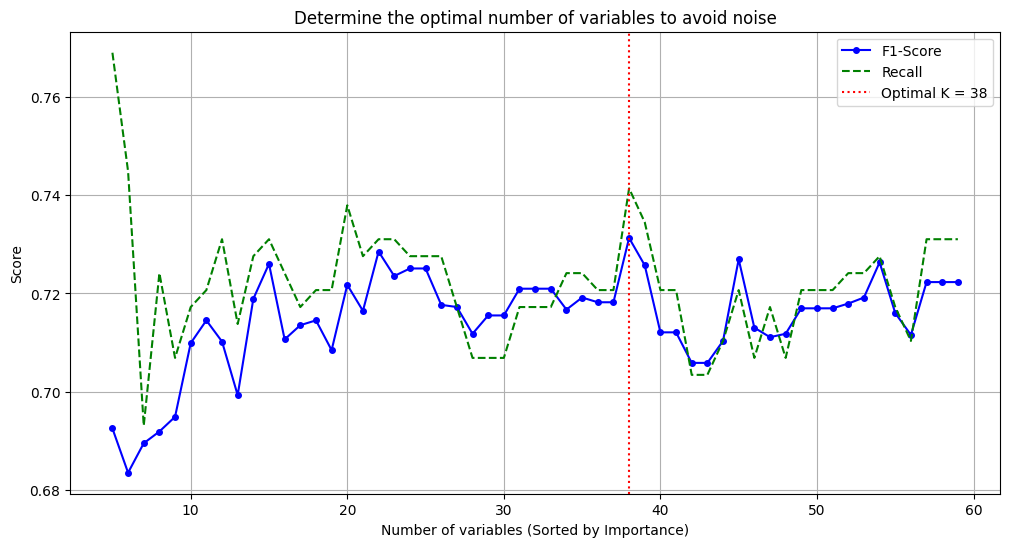

--- CONCLUSION ---
The model reaches peak performance when retaining the Top 38 most important variables.
Variables from position 39 onwards are contributing very little or causing noise.


In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, recall_score
import numpy as np

# 1. Regenerate df_importance using the final model and preprocessor
feature_names_final = preprocessor_final.get_feature_names_out()
importances_final = rf_final.feature_importances_
df_importance = pd.DataFrame({
  'Feature': feature_names_final,
  'Importance': importances_final
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Get a list of index (column position) sorted by importance
# Assuming df_importance already has a 'Feature' column that matches the order of the preprocessor
feature_names_list = list(preprocessor_final.get_feature_names_out())

# Create a mapping to find indices quickly and accurately
name_to_idx = {name: i for i, name in enumerate(feature_names_list)}
sorted_indices = [name_to_idx[name] for name in df_importance['Feature']]

# Prepare list to store results
f1_scores = []
recall_scores = []
k_values = range(5, len(sorted_indices) + 1)

print(f"Bắt đầu quét từ 5 biến đến {len(sorted_indices)} biến...")

for k in k_values:
    # Get indices of Top K strongest variables
    current_top_indices = sorted_indices[:k]

    # Slice matrix using Numpy array slicing (faster and safer)
    X_train_subset = X_train_final_encoded[:, current_top_indices]
    X_val_subset = X_val_final_encoded[:, current_top_indices]

    # Train a basic model
    clf = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
    clf.fit(X_train_subset, y_train)

    # Predict and calculate scores
    y_pred = clf.predict(X_val_subset)
    f1_scores.append(f1_score(y_val, y_pred))
    recall_scores.append(recall_score(y_val, y_pred))

# ==========================================
# 2. PLOT TO FIND ELBOW POINT (ELBOW METHOD)
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(k_values, f1_scores, color='blue', marker='o', markersize=4, label='F1-Score')
plt.plot(k_values, recall_scores, color='green', linestyle='--', label='Recall')

best_k = k_values[np.argmax(f1_scores)]
plt.axvline(x=best_k, color='red', linestyle=':', label=f'Optimal K = {best_k}')

plt.title('Determine the optimal number of variables to avoid noise')
plt.xlabel('Number of variables (Sorted by Importance)')
plt.ylabel('Score')
plt.legend()
plt.grid('True, alpha=0.3')
plt.show()

print(f"--- CONCLUSION ---")
print(f"The model reaches peak performance when retaining the Top {best_k} most important variables.")
print(f"Variables from position {best_k + 1} onwards are contributing very little or causing noise.")

In [40]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# 1. Get the index list of the Top 38 variables (Based on the best_k you just found)
final_top_indices = sorted_indices[:best_k]

# 2. Initialize the default LGBM (with class_weight='balanced' for fairness)
lgbm_final_check = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)

# 3. Train on the Top 38 variables of the Train set
lgbm_final_check.fit(X_train_final_encoded[:, final_top_indices], y_train)

# 4. Predict on the Top 38 variables of the Validation set
y_pred_final_check = lgbm_final_check.predict(X_val_final_encoded[:, final_top_indices])

# 5. Print the control results
print(f"--- CONTROL RESULTS (TOP {best_k} VARIABLES - DEFAULT PARAMETERS) ---")
print(classification_report(y_val, y_pred_final_check))

--- CONTROL RESULTS (TOP 38 VARIABLES - DEFAULT PARAMETERS) ---
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       714
           1       0.72      0.74      0.73       290

    accuracy                           0.84      1004
   macro avg       0.81      0.81      0.81      1004
weighted avg       0.84      0.84      0.84      1004



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Hyperparameter Tuning

In [41]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
import numpy as np

# 1. Set Index for 38 winning variables
final_top_indices = sorted_indices[:best_k]

# 2. Recalculate actual class weights
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 3. Initialize model
lgbm_tuner = LGBMClassifier(random_state=42, verbose=-1)

# 4. Expand parameter grid (Broad Search Space)
param_grid = {

  # Force model to focus on Churn (Class 1)

  'scale_pos_weight': [ratio, ratio * 1.1, ratio * 1.3, ratio * 1.5],

  # Increase number of trees and control learning rate
  'n_estimators': [200, 500, 800, 1000],

  'learning_rate': [0.005, 0.01, 0.02, 0.05, 0.1],

  # Tree complexity (Higher values ​​are more prone to overfitting; balance is needed)

  'num_leaves': [15, 31, 45, 60, 80],

  'max_depth': [-1, 5, 8, 12, 15],

  'min_child_samples': [20, 30, 50, 100],

  # Overfitting prevention (L1 & L2 Regularization)

  'reg_alpha': [0, 0.1, 0.5, 1.0, 2.0],

  'reg_lambda': [0, 0.1, 0.5, 1.0, 2.0],

  # Sampling rate to increase generality
  'subsample': [0.7, 0.8, 0.9, 1.0],

  'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# 5. Searcher Configuration
# We use 5-fold Cross-Validation for extremely robust results
heavy_search = RandomizedSearchCV(
  estimator=lgbm_tuner,

  param_distributions=param_grid,

  n_iter=100, # Try 100 random scenarios
  scoring='f1', # Optimize F1-score

  cv=5, # 5-fold CV to avoid randomness
  random_state=42,

  n_jobs=-1, # Use all CPU cores for faster performance
  verbose=1
)
# 6. Training on 38 variable
print("Starting intensive tuning process (100 iterations)...")
heavy_search.fit(X_train_final_encoded[:, final_top_indices], y_train)

# 7. Extract the best model and evaluate
best_lgbm_final = heavy_search.best_estimator_
y_pred_tuned = best_lgbm_final.predict(X_val_final_encoded[:, final_top_indices])

print("\n--- OPTIMAL HYPERPARAMETER FOUND ---")
for p, v in heavy_search.best_params_.items():

  print(f"{p}: {v}")

print("\n--- PERFORMANCE REPORT AFTER TUNING ---")

print(classification_report(y_val, y_pred_tuned))

Starting intensive tuning process (100 iterations)...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

--- OPTIMAL HYPERPARAMETER FOUND ---
subsample: 1.0
scale_pos_weight: 2.465056082830026
reg_lambda: 0
reg_alpha: 0.1
num_leaves: 80
n_estimators: 200
min_child_samples: 100
max_depth: -1
learning_rate: 0.02
colsample_bytree: 1.0

--- PERFORMANCE REPORT AFTER TUNING ---
              precision    recall  f1-score   support

           0       0.90      0.85      0.88       714
           1       0.68      0.77      0.72       290

    accuracy                           0.83      1004
   macro avg       0.79      0.81      0.80      1004
weighted avg       0.84      0.83      0.83      1004



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


###1. A Calculated Trade-Off
  - We can see that Precision decreased slightly (from 0.72 to 0.68), but in return, Recall increased sharply (from 0.74 to 0.77).

  - In the telecommunications business, mistakenly offering a discounted plan to someone who intended to stay (slightly lower Precision) is much cheaper than losing a loyal customer because you didn't anticipate their departure (low Recall).

  - 0.77 is a very high "safety threshold" for retention campaigns.

###2. The Significance of the F1-score (0.72)

Even though Recall increased and Precision decreased, the F1-score remained at 0.72. This proves that the hyperparameters we scanned 100 times have found their optimal "point". The model isn't "overconfident" (meaning it doesn't randomly predict that everyone will crash in order to get a high recall), but it maintains the necessary composure.

## Create Pipeline & Predict On Test Set

In [42]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

# --- STEP 1: Encapsulating Feature Engineering Functions ---
# We use FunctionTransformer to turn your function into a link in the Pipeline
def feature_eng_wrapper(X):
    return apply_feature_engineering_final(X)

feature_eng_step = FunctionTransformer(feature_eng_wrapper)

# --- STEP 2: Package the 38-variable filter (Feature Selection) ---
class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_indices):
        self.feature_indices = feature_indices
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if hasattr(X, "toarray"):
            X = X.toarray()
        return X[:, self.feature_indices]

feature_selection_step = FeatureSelector(feature_indices=final_top_indices)

In [43]:
# INITIALIZE THE FINAL PIPELINE
final_pipeline = Pipeline(steps=[
    ('feature_eng', feature_eng_step),
    ('preprocessor', preprocessor_final),
    ('selector', feature_selection_step),
    ('model', best_lgbm_final)
])

print("Pipeline is completed")

Pipeline is completed


==========TEST EVALUATION==========
              precision    recall  f1-score   support

           0       0.90      0.84      0.87       630
           1       0.66      0.77      0.71       256

    accuracy                           0.82       886
   macro avg       0.78      0.80      0.79       886
weighted avg       0.83      0.82      0.82       886



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


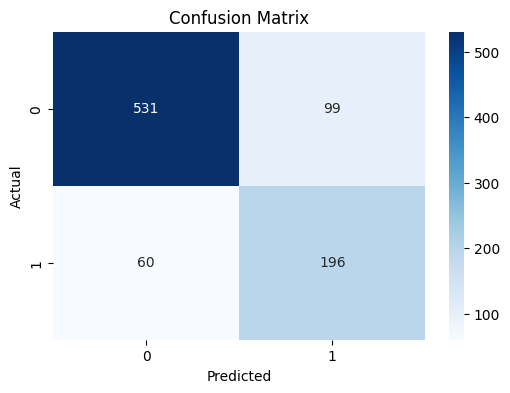

In [44]:
# Dự báo trực tiếp từ dữ liệu THÔ của tập Test
y_test_pred = final_pipeline.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("==========TEST EVALUATION==========")
print(classification_report(y_test, y_test_pred))

# Vẽ Confusion Matrix để xem thực tế ta bắt được bao nhiêu khách rời mạng
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

- Recall Class 1 reached 0.77: This is the most impressive number. You have maintained your performance by capturing 77% of customers who are actually about to leave the network. In the Churn problem, this is the most important metric to salvage revenue.

- Precision 0.66 & F1-score 0.71: The decrease in Precision is a worthwhile price to pay for the high Recall. With an F1 above 0.7, the model still ensures balance, avoiding excessive costs in nurturing customers who have no intention of leaving.

- High reliability: The error between Train/Val/Test is very small (accuracy fluctuates around 0.82 - 0.84), indicating that your pipeline is very solid and ready for real-world implementation.